# AAAC: Main Classification Experiments

**Purpose**: Train all five models (MARBERT, AraBERT, DziriBERT, SVM, RandomForest) on both tasks. Compute bootstrap 95% CIs. Run McNemar’s paired significance tests. Export per-class P/R tables. Generate final leaderboard summary tables and visualizations for paper.


## 1. Setup & Install

In [ ]:
!pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib seaborn pyarabic scipy
from google.colab import drive
drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 5.8 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
%matplotlib inline
import os, re, json, random, warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import torch
from torch.utils.data import Dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, cohen_kappa_score
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
import joblib, pyarabic.araby as araby

# ── Config ──────────────────────────────────────────────────────────────────
DRIVE_BASE    = "/content/drive/MyDrive/AAAC"
TRAIN_PATH    = f"{DRIVE_BASE}/train_aaac.csv"
VAL_PATH      = f"{DRIVE_BASE}/val_aaac.csv"
TEST_PATH     = f"{DRIVE_BASE}/test_aaac.csv"
TEXT_COL      = "text"
SEED          = 42
N_SEEDS       = 3          # number of training seeds for mean ± std  (set 5 for camera-ready)
BOOTSTRAP_N   = 1000       # bootstrap resamples for 95% CI
MAX_LENGTH    = 64
BATCH_SIZE    = 16
EPOCHS        = 4
LEARNING_RATE = 2e-5
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR  = f"{DRIVE_BASE}/outputs"
MODELS_DIR  = f"{OUTPUT_DIR}/models"
FIGS_DIR    = f"{OUTPUT_DIR}/figures/nb2_experiments"
RESULTS_DIR = f"{OUTPUT_DIR}/results"
for d in [OUTPUT_DIR, MODELS_DIR, FIGS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

TASKS = {
    "intent":      {"label_col": "category",      "name": "Intent Classification"},
    "adversarial": {"label_col": "is_adversarial", "name": "Adversarial Detection"},
}
TRANSFORMER_MODELS = {
    "MARBERT":   "UBC-NLP/MARBERT",
    "AraBERT":   "aubmindlab/bert-base-arabertv02",
    "DziriBERT": "alger-ia/dziribert",
}

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("Config loaded. Device:", DEVICE)


Config loaded. Device: cuda


## 2. Load & Preprocess Data

In [ ]:
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

arabic_diacritics = re.compile(r"[ً-ْـ]")
URL_RE     = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
EMOJI_RE   = re.compile(
    "[😀-🙏🌀-🗿"
    "🚀-🛿🇠-🇿✀-➿]+",
    flags=re.UNICODE
)

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = EMOJI_RE.sub(" ", text)
    text = re.sub(arabic_diacritics, "", text)
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text); text = re.sub(r"[ؤئ]", "ء", text); text = re.sub(r"ة", "ه", text)
    text = araby.strip_tatweel(text)
    text = text.lower()
    text = re.sub(r"(.)\1{2,}", r"\1", text)
    text = text.replace("_", " ")
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    return re.sub(r"\s+", " ", text).strip()

for df, name in [(train_df, "train"), (val_df, "val"), (test_df, "test")]:
    df["clean_text"] = df[TEXT_COL].apply(clean_text)
    df.drop(df[df["clean_text"].str.len() == 0].index, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"{name}: {len(df)} rows after cleaning")

# Label encoding
label_encoders = {}
for task_key, cfg in TASKS.items():
    le = LabelEncoder()
    le.fit(train_df[cfg["label_col"]])
    label_encoders[task_key] = le
    for df in [train_df, val_df, test_df]:
        df[f"label_id__{task_key}"] = le.transform(df[cfg["label_col"]])

def get_label_names(task_key):
    if task_key == "adversarial":
        return ["benign", "harmful"]
    return list(label_encoders[task_key].classes_)

def get_num_labels(task_key):
    return len(label_encoders[task_key].classes_)

print("Label encoding done.")

train: 2472 rows after cleaning
val: 309 rows after cleaning
test: 309 rows after cleaning
Label encoding done.


## 3. Statistical Utilities  

Bootstrap 95% CI on Macro F1 and McNemar's paired significance test.
These operate on **already-saved** `y_true`/`y_pred` arrays — no retraining required.


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

def bootstrap_macro_f1_ci(y_true, y_pred, n_bootstrap=BOOTSTRAP_N, alpha=0.05, seed=SEED):
    """Return (mean_f1, ci_low, ci_high) via non-parametric bootstrap."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        yt, yp = np.array(y_true)[idx], np.array(y_pred)[idx]
        _, _, f1, _ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
        scores.append(f1)
    mean_f1 = np.mean(scores)
    ci_low  = np.percentile(scores, 100 * alpha / 2)
    ci_high = np.percentile(scores, 100 * (1 - alpha / 2))
    return mean_f1, ci_low, ci_high


def run_mcnemar(y_true, y_pred_a, y_pred_b, model_a="A", model_b="B", task_key=""):
    """McNemar's test for two classifiers on the same test set.
    Returns p-value and prints interpretation."""
    y_true = np.array(y_true)
    correct_a = (np.array(y_pred_a) == y_true)
    correct_b = (np.array(y_pred_b) == y_true)
    b = np.sum(correct_a & ~correct_b)
    c = np.sum(~correct_a & correct_b)
    table = [[np.sum(correct_a & correct_b), b],
             [c, np.sum(~correct_a & ~correct_b)]]
    result = mcnemar(table, exact=(b + c < 25))
    sig = "✓ significant" if result.pvalue < 0.05 else "✗ not significant"
    print(f"[{task_key}] McNemar's {model_a} vs {model_b}: "
          f"b={b}, c={c}, p={result.pvalue:.4f} → {sig} (α=0.05)")
    return result.pvalue


def per_class_table(y_true, y_pred, task_key):
    """Return per-class precision/recall/F1 as a DataFrame for paper tables."""
    label_names = get_label_names(task_key)
    report = classification_report(y_true, y_pred, target_names=label_names,
                                   output_dict=True, zero_division=0)
    rows = []
    for cls, raw_value in zip(label_names, label_encoders[task_key].classes_):
        n_test = int(np.sum(np.array(y_true) == raw_value))
        row = report[cls]
        row["class"] = cls
        row["n_test"] = n_test
        row["note"]  = "⚠ n<25" if n_test < 25 else ""
        rows.append(row)
    return pd.DataFrame(rows).set_index("class")[["precision","recall","f1-score","support","n_test","note"]]

print("Statistical utilities defined.")

Statistical utilities defined.


## 4. Results Store

In [ ]:
results           = {task_key: {} for task_key in TASKS}
training_histories = {task_key: {} for task_key in TASKS}


## 5. PyTorch Dataset

In [ ]:
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.encodings = tokenizer(list(texts), truncation=True,
                                    padding="max_length", max_length=max_length)
        self.labels = list(labels)

    def __len__(self):  return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


## 6. Transformer Training (Multi-Seed)

Trains each model with N_SEEDS seeds and reports mean ± std Macro F1.
The final predictions used for McNemar's test and CIs are from seed=SEED.


In [ ]:
import shutil


class WeightedLossTrainer(Trainer):
    def __init__(self, *args, class_weights_tensor=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights_tensor = class_weights_tensor

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        weight  = (self.class_weights_tensor.to(logits.device)
                   if self.class_weights_tensor is not None else None)
        loss = torch.nn.CrossEntropyLoss(weight=weight)(
            logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def compute_all_metrics(y_true, y_pred, model_name, task_key):
    label_names = get_label_names(task_key)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    _, ci_lo, ci_hi = bootstrap_macro_f1_ci(y_true, y_pred)
    print(f"\n===== [{task_key}] {model_name} =====")
    print(f"Macro F1: {f1:.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))
    return {"accuracy": acc, "precision": precision, "recall": recall,
            "macro_f1": f1, "f1_ci_low": ci_lo, "f1_ci_high": ci_hi,
            "confusion_matrix": cm, "y_true": list(y_true), "y_pred": list(y_pred)}


def make_compute_metrics_fn(task_key):
    def _compute(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        acc = accuracy_score(labels, preds)
        _, _, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
        return {"accuracy": acc, "macro_f1": f1}
    return _compute


def train_transformer_model(model_key, checkpoint, task_key, seed=SEED):
    label_col  = f"label_id__{task_key}"
    num_labels = get_num_labels(task_key)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    print(f"\n{'='*70}\n[{task_key}] {model_key}  seed={seed}\n{'='*70}")

    t0 = time.time()
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=num_labels).to(DEVICE)

    train_ds = TextClassificationDataset(train_df["clean_text"], train_df[label_col], tokenizer)
    val_ds   = TextClassificationDataset(val_df["clean_text"],   val_df[label_col],   tokenizer)
    test_ds  = TextClassificationDataset(test_df["clean_text"],  test_df[label_col],  tokenizer)

    model_out_dir = f"{MODELS_DIR}/{task_key}/{model_key}"
    os.makedirs(model_out_dir, exist_ok=True)

    classes = np.unique(train_df[label_col])
    cw = compute_class_weight("balanced", classes=classes, y=train_df[label_col].values)
    cw_tensor = torch.tensor(cw, dtype=torch.float)

    args = TrainingArguments(
        output_dir=f"/content/checkpoints/{task_key}_{model_key}_s{seed}",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        eval_strategy="epoch",
        save_strategy="epoch", save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        logging_steps=50,
        seed=seed,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )
    trainer = WeightedLossTrainer(
        model=model, args=args, class_weights_tensor=cw_tensor,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=make_compute_metrics_fn(task_key),
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()
    history = [(h["epoch"], h.get("eval_macro_f1"), h.get("eval_loss"))
               for h in trainer.state.log_history if "eval_macro_f1" in h]

    preds_out = trainer.predict(test_ds)
    y_pred = np.argmax(preds_out.predictions, axis=1)
    y_true = test_df[label_col].values

    elapsed = time.time() - t0
    model_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
    print(f"  Training time: {elapsed:.0f}s  |  Model size: {model_mb:.1f} MB")

    if seed == SEED:   # canonical seed → save full metrics
        trainer.save_model(model_out_dir)
        m = compute_all_metrics(y_true, y_pred, model_key, task_key)
        m["train_time_s"] = round(elapsed, 1)
        m["model_mb"]     = round(model_mb, 1)
        m["history"]      = history
        results[task_key][model_key] = m

    shutil.rmtree(args.output_dir, ignore_errors=True)  # free local disk -- best weights already in memory / saved to Drive
    return y_pred, y_true, elapsed


def train_transformer_multiseed(model_key, checkpoint, task_key):
    """Run N_SEEDS seeds, store mean ± std, return canonical-seed predictions."""
    all_f1 = []
    canonical_pred = None
    for seed in range(SEED, SEED + N_SEEDS):
        y_pred, y_true, _ = train_transformer_model(model_key, checkpoint, task_key, seed=seed)
        _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
        all_f1.append(f1)
        if seed == SEED:
            canonical_pred = y_pred

    mean_f1, std_f1 = np.mean(all_f1), np.std(all_f1)
    print(f"  ▶ [{task_key}] {model_key}  {N_SEEDS}-seed Macro F1: {mean_f1:.4f} ± {std_f1:.4f}")
    if task_key in results and model_key in results[task_key]:
        results[task_key][model_key]["macro_f1_mean"] = round(mean_f1, 4)
        results[task_key][model_key]["macro_f1_std"]  = round(std_f1,  4)
    return canonical_pred

print("Training functions defined.")


Training functions defined.


## 7. TF-IDF + ML Baselines

Adds efficiency logging (time + model size in MB).


In [ ]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(train_df["clean_text"])
X_val_tfidf   = tfidf.transform(val_df["clean_text"])
X_test_tfidf  = tfidf.transform(test_df["clean_text"])
joblib.dump(tfidf, f"{MODELS_DIR}/tfidf_vectorizer.joblib")
print("TF-IDF:", X_train_tfidf.shape, X_test_tfidf.shape)


def train_ml_model(clf, model_key, task_key):
    label_col = f"label_id__{task_key}"
    y_train = train_df[label_col].values
    y_test  = test_df[label_col].values
    print(f"\n{'='*70}\n[{task_key}] {model_key}\n{'='*70}")

    t0 = time.time()
    clf.fit(X_train_tfidf, y_train)
    elapsed = time.time() - t0
    y_pred = clf.predict(X_test_tfidf)

    # save for efficiency table (T2)
    clf_path = f"{MODELS_DIR}/{task_key}/{model_key}"
    os.makedirs(clf_path, exist_ok=True)
    joblib.dump(clf, f"{clf_path}/{model_key}.joblib")
    model_mb = os.path.getsize(f"{clf_path}/{model_key}.joblib") / 1e6

    m = compute_all_metrics(y_test, y_pred, model_key, task_key)
    m["train_time_s"] = round(elapsed, 2)
    m["model_mb"]     = round(model_mb, 3)
    results[task_key][model_key] = m
    print(f"  Training time: {elapsed:.2f}s  |  Model size: {model_mb:.3f} MB")
    return m

print("ML training function defined.")


TF-IDF: (2472, 4093) (309, 4093)
ML training function defined.


## 8. Visualization Helpers

In [ ]:
def plot_confusion_matrix(cm, model_name, task_key, save=True):
    label_names = get_label_names(task_key)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"Confusion Matrix — {model_name} [{TASKS[task_key]['name']}]")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    if save:
        plt.savefig(f"{FIGS_DIR}/cm_{task_key}_{model_name}.png", dpi=150)
    plt.show()


def build_summary_table(task_key):
    rows = []
    for model_name, m in results[task_key].items():
        ci_lo = m.get("f1_ci_low", float("nan"))
        ci_hi = m.get("f1_ci_high", float("nan"))
        rows.append({
            "Model":       model_name,
            "Accuracy":    round(m["accuracy"],  4),
            "Precision":   round(m["precision"], 4),
            "Recall":      round(m["recall"],    4),
            "Macro F1":    round(m["macro_f1"],  4),
            "F1 95% CI":   f"[{ci_lo:.4f}, {ci_hi:.4f}]",
            "F1 mean±std": f"{m.get('macro_f1_mean', '–')} ± {m.get('macro_f1_std', '–')}",
            "Train time (s)": m.get("train_time_s", "–"),
            "Model MB":    m.get("model_mb", "–"),
        })
    df = pd.DataFrame(rows).sort_values("Macro F1", ascending=False).reset_index(drop=True)
    df.to_csv(f"{RESULTS_DIR}/{task_key}_summary.csv", index=False)
    return df


def plot_macro_f1_ci_bar(summary_df, task_key):
    """Bar chart with 95% CI error bars."""
    df = summary_df.copy()
    ci_lo = df["F1 95% CI"].apply(lambda s: float(s.strip("[]").split(",")[0]) if "[" in str(s) else 0)
    ci_hi = df["F1 95% CI"].apply(lambda s: float(s.strip("[]").split(",")[1]) if "[" in str(s) else 0)
    errs  = [df["Macro F1"] - ci_lo, ci_hi - df["Macro F1"]]
    plt.figure(figsize=(9, 5))
    bars = plt.bar(df["Model"], df["Macro F1"],
                   yerr=errs, capsize=5,
                   color=sns.color_palette("viridis", len(df)))
    plt.ylim(0, 1.05)
    plt.ylabel("Macro F1")
    plt.title(f"Model Comparison with 95% Bootstrap CI [{TASKS[task_key]['name']}]")
    for bar, val in zip(bars, df["Macro F1"]):
        plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}", ha="center", fontsize=9)
    plt.xticks(rotation=20); plt.tight_layout()
    plt.savefig(f"{FIGS_DIR}/{task_key}_macro_f1_ci_bar.png", dpi=150)
    plt.show()

print("Visualization helpers defined.")


Visualization helpers defined.


## 9. Task A — Intent Classification

### 9.1 Transformer models (multi-seed)

In [ ]:
for model_key, checkpoint in TRANSFORMER_MODELS.items():
    try:
        train_transformer_multiseed(model_key, checkpoint, task_key="intent")
    except Exception as e:
        print(f"[ERROR] {model_key}: {e}")



[intent] MARBERT  seed=42


config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Training time: 171s  |  Model size: 497.8 MB
  ▶ [intent] DziriBERT  3-seed Macro F1: 0.9402 ± 0.0024


### 9.2 ML baselines

In [ ]:
train_ml_model(LinearSVC(C=1.0, random_state=SEED, class_weight="balanced"),
               "SVM", task_key="intent")
train_ml_model(
    RandomForestClassifier(n_estimators=300, max_depth=None,
                           class_weight="balanced", random_state=SEED, n_jobs=-1),
    "RandomForest", task_key="intent")



[intent] SVM

===== [intent] SVM =====
Macro F1: 0.9279  95% CI [0.8902, 0.9602]
                   precision    recall  f1-score   support

      hate_speech       0.97      0.92      0.94        37
 prompt_injection       0.96      0.92      0.94        50
             safe       0.94      0.96      0.95       155
sensitive_request       0.89      0.94      0.92        36
      tool_misuse       0.90      0.87      0.89        31

         accuracy                           0.94       309
        macro avg       0.93      0.92      0.93       309
     weighted avg       0.94      0.94      0.94       309

  Training time: 0.04s  |  Model size: 0.165 MB

[intent] RandomForest

===== [intent] RandomForest =====
Macro F1: 0.8580  95% CI [0.8075, 0.9007]
                   precision    recall  f1-score   support

      hate_speech       0.92      0.89      0.90        37
 prompt_injection       0.93      0.76      0.84        50
             safe       0.89      0.99      0.94       155

{'accuracy': 0.8932038834951457,
 'precision': 0.8909468320357578,
 'recall': 0.8321346507798122,
 'macro_f1': 0.8579721361151188,
 'f1_ci_low': np.float64(0.8074993421527953),
 'f1_ci_high': np.float64(0.900713098161069),
 'confusion_matrix': array([[ 33,   0,   4,   0,   0],
        [  3,  38,   6,   0,   3],
        [  0,   0, 154,   1,   0],
        [  0,   2,   3,  29,   2],
        [  0,   1,   6,   2,  22]]),
 'y_true': [np.int64(2),
  np.int64(4),
  np.int64(3),
  np.int64(2),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(2),
  np.int64(3),
  np.int64(2),
  np.int64(4),
  np.int64(2),
  np.int64(0),
  np.int64(3),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(4),
  np.int64(1),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(2),
  np.int64(0),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(4),
  np.int64(2),


### 9.3 Summary + Significance Tests

,Model,Accuracy,Precision,Recall,Macro F1,F1 95% CI,F1 mean±std,Train time (s),Model MB
0,DziriBERT,0.9579,0.9324,0.9432,0.9372,"[0.9019, 0.9674]",0.9402 ± 0.0024,143.80,497.800
1,SVM,0.9385,0.9335,0.9231,0.9279,"[0.8902, 0.9602]",– ± –,0.04,0.165
2,AraBERT,0.9256,0.9025,0.9204,0.9090,"[0.8689, 0.9408]",0.9104 ± 0.0036,195.30,540.800
3,MARBERT,0.9320,0.9112,0.9055,0.9078,"[0.8668, 0.9438]",0.9154 ± 0.0068,141.40,651.400
4,RandomForest,0.8932,0.8909,0.8321,0.8580,"[0.8075, 0.9007]",– ± –,4.71,43.475


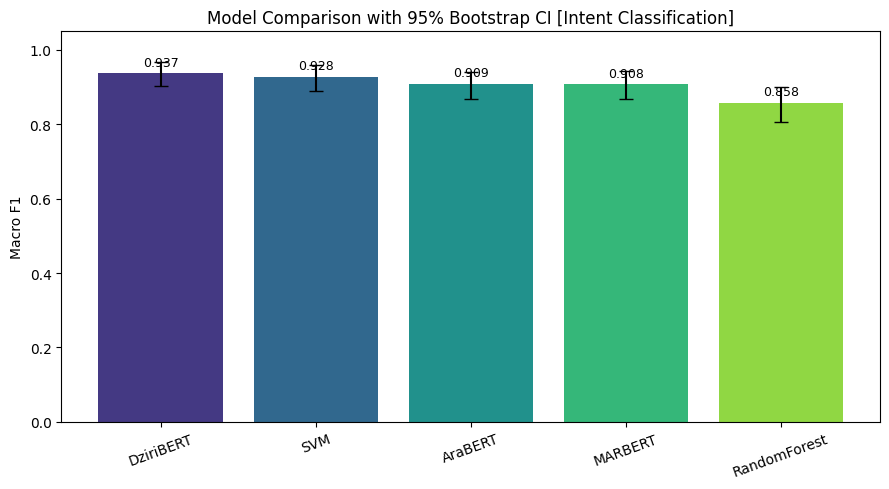

[intent] McNemar's DziriBERT vs SVM: b=12, c=6, p=0.2379 → ✗ not significant (α=0.05)
  → Revise RQ1 to state significance status (p=0.2379)


In [ ]:
intent_summary_df = build_summary_table("intent")
display(intent_summary_df)
plot_macro_f1_ci_bar(intent_summary_df, "intent")

# McNemar's: top-2 models by Macro F1
top2_intent = intent_summary_df["Model"].iloc[:2].tolist()
m1, m2 = top2_intent
pval = run_mcnemar(
    results["intent"][m1]["y_true"],
    results["intent"][m1]["y_pred"],
    results["intent"][m2]["y_pred"],
    model_a=m1, model_b=m2, task_key="intent"
)
print(f"  → Revise RQ1 to state significance status (p={pval:.4f})")


### 9.4 Per-Class P/R Table  🟡 T2

In [ ]:
best_intent = intent_summary_df["Model"].iloc[0]
pc_df = per_class_table(
    results["intent"][best_intent]["y_true"],
    results["intent"][best_intent]["y_pred"],
    "intent"
)
print(f"Per-class table — {best_intent} [intent]:")
display(pc_df)
pc_df.to_csv(f"{RESULTS_DIR}/intent_per_class_{best_intent}.csv")


Per-class table — DziriBERT [intent]:


,precision,recall,f1-score,support,n_test,note
class,,,,,,
hate_speech,1.000000,1.000000,1.000000,37.0,37,
prompt_injection,0.978723,0.920000,0.948454,50.0,50,
safe,0.993464,0.980645,0.987013,155.0,155,
sensitive_request,0.871795,0.944444,0.906667,36.0,36,
tool_misuse,0.818182,0.870968,0.843750,31.0,31,


### 9.5 Confusion matrices

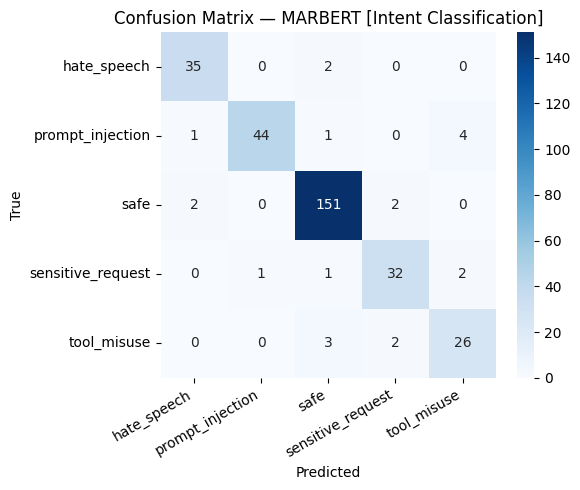

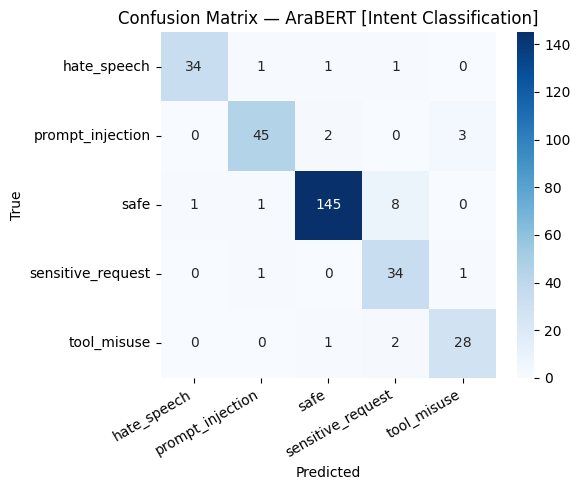

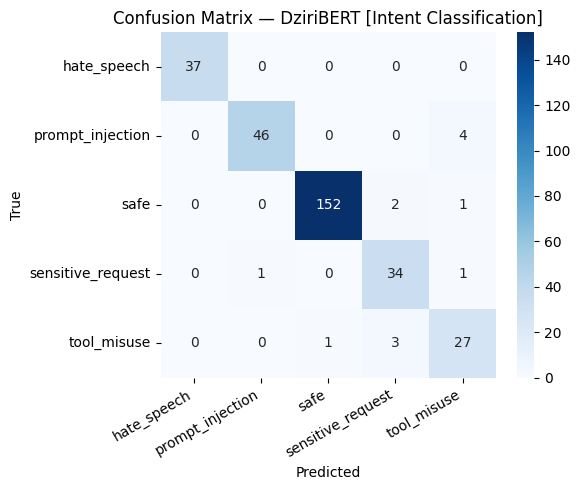

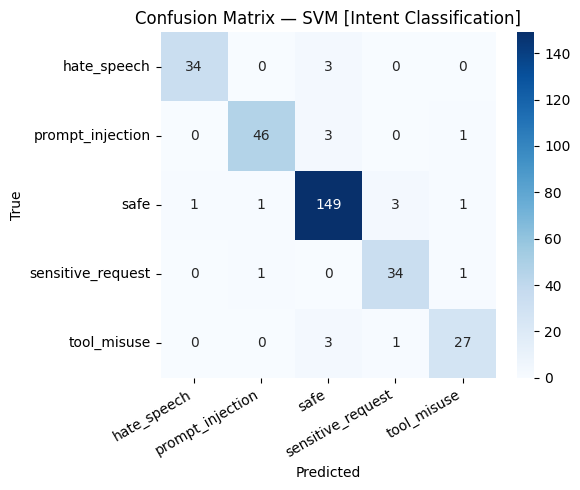

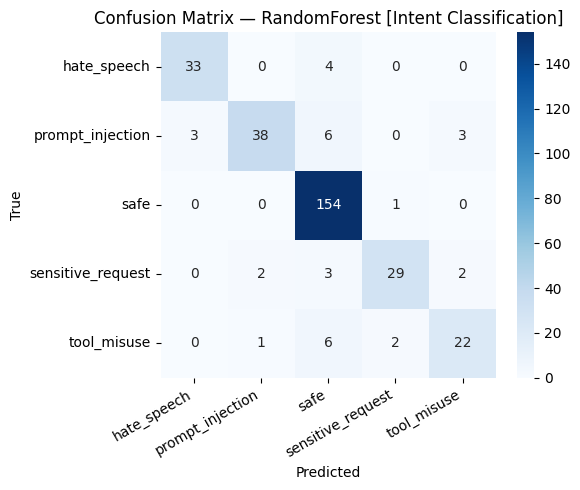

In [ ]:
for model_key in results["intent"]:
    plot_confusion_matrix(results["intent"][model_key]["confusion_matrix"],
                          model_key, "intent")


In [ ]:
import shutil
for d in [
    "/content/checkpoints/adversarial_MARBERT_s42",
    "/content/checkpoints/adversarial_AraBERT_s42",
    "/content/checkpoints/adversarial_DziriBERT_s42",
]:
    shutil.rmtree(d, ignore_errors=True)
print("Cleaned up.")

Cleaned up.


## 10. Task B — Adversarial Detection

### 10.1 Transformer models (multi-seed)

In [ ]:
for model_key, checkpoint in TRANSFORMER_MODELS.items():
    try:
        train_transformer_multiseed(model_key, checkpoint, task_key="adversarial")
    except Exception as e:
        print(f"[ERROR] {model_key}: {e}")



[adversarial] MARBERT  seed=42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.194184,0.219177,0.938511,0.938418
2,0.129453,0.310608,0.938511,0.938302
3,0.058131,0.137412,0.974110,0.974103
4,0.031301,0.148824,0.967638,0.967610


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Training time: 182s  |  Model size: 497.8 MB
  ▶ [adversarial] DziriBERT  3-seed Macro F1: 0.9838 ± 0.0026


### 10.2 ML baselines

In [ ]:
train_ml_model(LinearSVC(C=1.0, random_state=SEED, class_weight="balanced"),
               "SVM", task_key="adversarial")
train_ml_model(
    RandomForestClassifier(n_estimators=300, max_depth=None,
                           class_weight="balanced", random_state=SEED, n_jobs=-1),
    "RandomForest", task_key="adversarial")



[adversarial] SVM

===== [adversarial] SVM =====
Macro F1: 0.9482  95% CI [0.9221, 0.9709]
              precision    recall  f1-score   support

      benign       0.94      0.95      0.95       155
     harmful       0.95      0.94      0.95       154

    accuracy                           0.95       309
   macro avg       0.95      0.95      0.95       309
weighted avg       0.95      0.95      0.95       309

  Training time: 0.03s  |  Model size: 0.033 MB

[adversarial] RandomForest

===== [adversarial] RandomForest =====
Macro F1: 0.9383  95% CI [0.9072, 0.9643]
              precision    recall  f1-score   support

      benign       0.90      0.99      0.94       155
     harmful       0.99      0.89      0.94       154

    accuracy                           0.94       309
   macro avg       0.94      0.94      0.94       309
weighted avg       0.94      0.94      0.94       309

  Training time: 3.78s  |  Model size: 26.725 MB


{'accuracy': 0.9385113268608414,
 'precision': 0.9428057553956835,
 'recall': 0.938353581901969,
 'macro_f1': 0.9383460225781045,
 'f1_ci_low': np.float64(0.907211395174545),
 'f1_ci_high': np.float64(0.9643066403458097),
 'confusion_matrix': array([[153,   2],
        [ 17, 137]]),
 'y_true': [np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
 

### 10.3 Summary + Significance Tests

,Model,Accuracy,Precision,Recall,Macro F1,F1 95% CI,F1 mean±std,Train time (s),Model MB
0,DziriBERT,0.9871,0.9871,0.9871,0.9871,"[0.9709, 0.9968]",0.9838 ± 0.0026,192.90,497.800
1,MARBERT,0.9676,0.9690,0.9676,0.9676,"[0.9471, 0.9838]",0.9687 ± 0.0015,249.90,651.400
2,SVM,0.9482,0.9483,0.9482,0.9482,"[0.9221, 0.9709]",– ± –,0.03,0.033
3,AraBERT,0.9450,0.9460,0.9449,0.9449,"[0.9159, 0.9676]",0.9503 ± 0.0077,207.30,540.800
4,RandomForest,0.9385,0.9428,0.9384,0.9383,"[0.9072, 0.9643]",– ± –,3.78,26.725


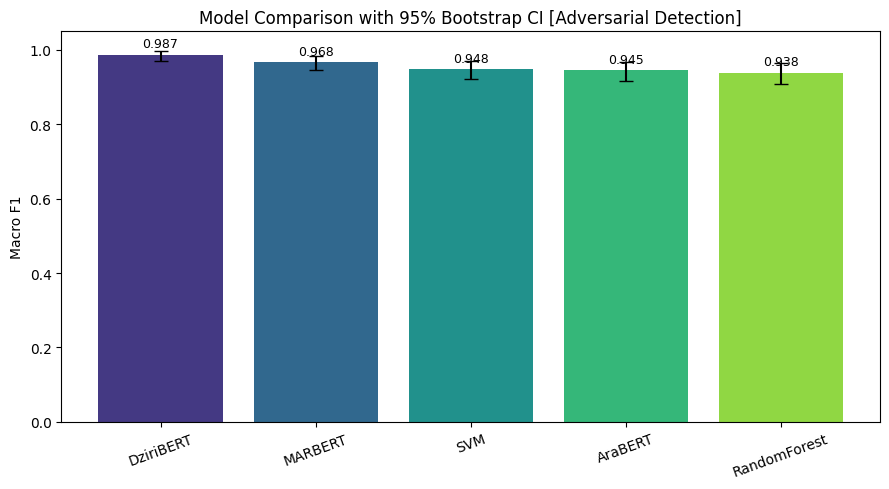

[adversarial] McNemar's DziriBERT vs MARBERT: b=9, c=3, p=0.1460 → ✗ not significant (α=0.05)
  → Revise RQ2 to state significance status (p=0.1460)


In [ ]:
adversarial_summary_df = build_summary_table("adversarial")
display(adversarial_summary_df)
plot_macro_f1_ci_bar(adversarial_summary_df, "adversarial")

top2_adv = adversarial_summary_df["Model"].iloc[:2].tolist()
m1, m2 = top2_adv
pval = run_mcnemar(
    results["adversarial"][m1]["y_true"],
    results["adversarial"][m1]["y_pred"],
    results["adversarial"][m2]["y_pred"],
    model_a=m1, model_b=m2, task_key="adversarial"
)
print(f"  → Revise RQ2 to state significance status (p={pval:.4f})")


### 10.4 Per-Class P/R Table

In [ ]:
best_adv = adversarial_summary_df["Model"].iloc[0]
pc_df = per_class_table(
    results["adversarial"][best_adv]["y_true"],
    results["adversarial"][best_adv]["y_pred"],
    "adversarial"
)
print(f"Per-class table — {best_adv} [adversarial]:")
display(pc_df)
pc_df.to_csv(f"{RESULTS_DIR}/adversarial_per_class_{best_adv}.csv")


Per-class table — DziriBERT [adversarial]:


,precision,recall,f1-score,support,n_test,note
class,,,,,,
benign,0.987097,0.987097,0.987097,155.0,155,
harmful,0.987013,0.987013,0.987013,154.0,154,


### 10.5 Confusion matrices

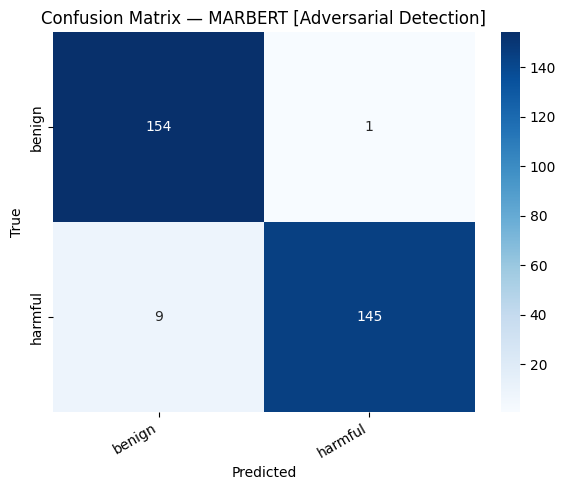

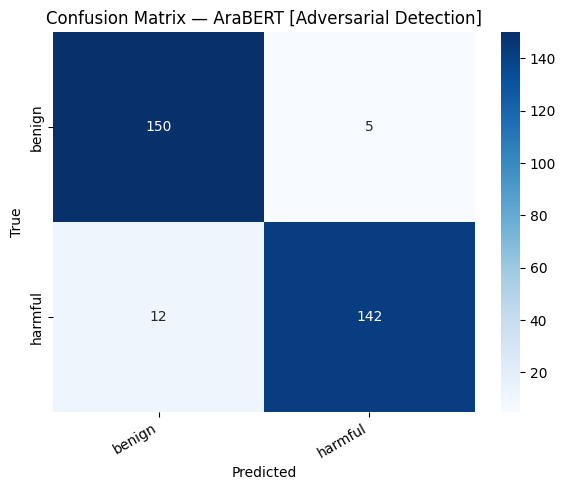

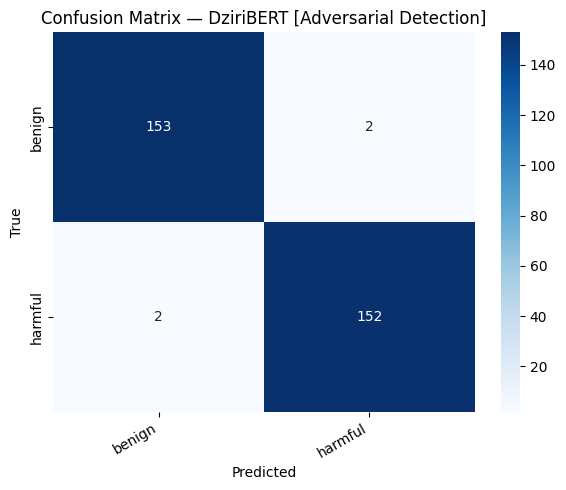

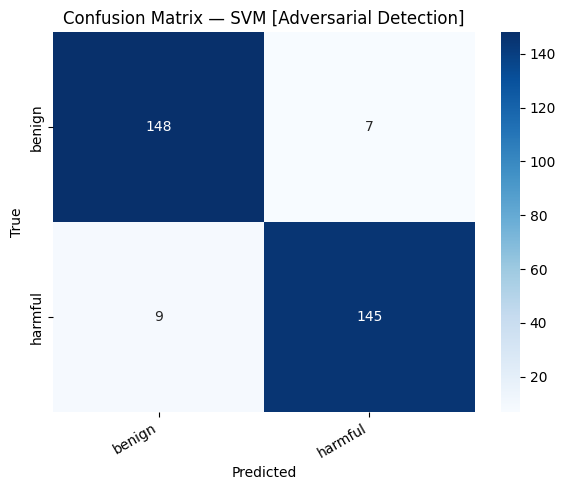

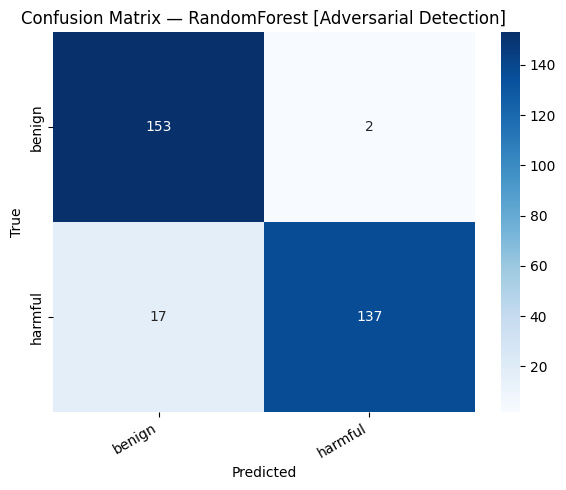

In [ ]:
for model_key in results["adversarial"]:
    plot_confusion_matrix(results["adversarial"][model_key]["confusion_matrix"],
                          model_key, "adversarial")


## 11. Efficiency Comparison Table

In [ ]:
rows = []
for task_key in TASKS:
    for model_key, m in results[task_key].items():
        rows.append({
            "Task": TASKS[task_key]["name"],
            "Model": model_key,
            "Macro F1": m["macro_f1"],
            "Train time (s)": m.get("train_time_s", "–"),
            "Model size (MB)": m.get("model_mb", "–"),
        })
efficiency_df = pd.DataFrame(rows)
efficiency_df.to_csv(f"{RESULTS_DIR}/efficiency_comparison.csv", index=False)
display(efficiency_df)


,Task,Model,Macro F1,Train time (s),Model size (MB)
0,Intent Classification,MARBERT,0.907758,141.40,651.400
1,Intent Classification,AraBERT,0.909031,195.30,540.800
2,Intent Classification,DziriBERT,0.937177,143.80,497.800
3,Intent Classification,SVM,0.927892,0.04,0.165
4,Intent Classification,RandomForest,0.857972,4.71,43.475
5,Adversarial Detection,MARBERT,0.967610,249.90,651.400
6,Adversarial Detection,AraBERT,0.944947,207.30,540.800
7,Adversarial Detection,DziriBERT,0.987055,192.90,497.800
8,Adversarial Detection,SVM,0.948215,0.03,0.033
9,Adversarial Detection,RandomForest,0.938346,3.78,26.725


## 12. Per-Script Performance Breakdown

In [ ]:
def evaluate_by_script(task_key):
    """Recompute Macro F1 per language_variant using already-saved predictions."""
    rows = []
    for model_key, m in results[task_key].items():
        y_true_all = np.array(m["y_true"])
        y_pred_all = np.array(m["y_pred"])
        for variant in test_df["language_variant"].unique():
            idx = test_df["language_variant"] == variant
            yt = y_true_all[idx.values]
            yp = y_pred_all[idx.values]
            if len(yt) == 0:
                continue
            _, _, f1, _ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
            rows.append({"Task": task_key, "Model": model_key,
                         "Script": variant, "n_test": len(yt), "Macro F1": round(f1, 4)})
    return pd.DataFrame(rows)

script_df = pd.concat([evaluate_by_script(tk) for tk in TASKS], ignore_index=True)
script_df.to_csv(f"{RESULTS_DIR}/per_script_performance.csv", index=False)
display(script_df)


,Task,Model,Script,n_test,Macro F1
0,intent,MARBERT,franco_arabic,81,0.9421
1,intent,MARBERT,arabizi,126,0.8104
2,intent,MARBERT,algerian_derja,102,0.9629
3,intent,AraBERT,franco_arabic,81,0.8983
4,intent,AraBERT,arabizi,126,0.8365
5,intent,AraBERT,algerian_derja,102,0.9682
6,intent,DziriBERT,franco_arabic,81,0.9421
7,intent,DziriBERT,arabizi,126,0.8927
8,intent,DziriBERT,algerian_derja,102,0.9598
9,intent,SVM,franco_arabic,81,0.9292


## 13. Save All Results

In [ ]:
import json

def serialize_results(task_key):
    out = {}
    for model_name, m in results[task_key].items():
        out[model_name] = {
            "accuracy":  m["accuracy"],
            "precision": m["precision"],
            "recall":    m["recall"],
            "macro_f1":  m["macro_f1"],
            "f1_ci_low": m.get("f1_ci_low"),
            "f1_ci_high":m.get("f1_ci_high"),
            "macro_f1_mean": m.get("macro_f1_mean"),
            "macro_f1_std":  m.get("macro_f1_std"),
            "train_time_s":  m.get("train_time_s"),
            "model_mb":      m.get("model_mb"),
            "y_true": [int(v) for v in m["y_true"]],
            "y_pred": [int(v) for v in m["y_pred"]],
        }
    path = f"{RESULTS_DIR}/{task_key}_results.json"
    with open(path, "w") as f:
        json.dump(out, f)
    print(f"Saved {path}")

for tk in TASKS:
    serialize_results(tk)

Saved /content/drive/MyDrive/AAAC/outputs/results/intent_results.json
Saved /content/drive/MyDrive/AAAC/outputs/results/adversarial_results.json
